In [1]:
import pandas as pd
df = pd.read_csv("student_habits_performance.csv")

In [32]:
import numpy as np

In [2]:
df.head()

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


In [3]:
df.describe()

,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,exam_score
count,1000.0000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.4980,3.55010,2.505500,1.819700,84.131700,6.470100,3.042000,5.438000,69.601500
std,2.3081,1.46889,1.172422,1.075118,9.399246,1.226377,2.025423,2.847501,16.888564
min,17.0000,0.00000,0.000000,0.000000,56.000000,3.200000,0.000000,1.000000,18.400000
25%,18.7500,2.60000,1.700000,1.000000,78.000000,5.600000,1.000000,3.000000,58.475000
50%,20.0000,3.50000,2.500000,1.800000,84.400000,6.500000,3.000000,5.000000,70.500000
75%,23.0000,4.50000,3.300000,2.525000,91.025000,7.300000,5.000000,8.000000,81.325000
max,24.0000,8.30000,7.200000,5.400000,100.000000,10.000000,6.000000,10.000000,100.000000


In [5]:
df.isna().sum()

student_id                        0
age                               0
gender                            0
study_hours_per_day               0
social_media_hours                0
netflix_hours                     0
part_time_job                     0
attendance_percentage             0
sleep_hours                       0
diet_quality                      0
exercise_frequency                0
parental_education_level         91
internet_quality                  0
mental_health_rating              0
extracurricular_participation     0
exam_score                        0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.describe(include = 'object')

,student_id,gender,part_time_job,diet_quality,parental_education_level,internet_quality,extracurricular_participation
count,1000,1000,1000,1000,909,1000,1000
unique,1000,3,2,3,3,3,2
top,S1000,Female,No,Fair,High School,Good,No
freq,1,481,785,437,392,447,682


In [13]:
df.columns

Index(['student_id', 'age', 'gender', 'study_hours_per_day',
       'social_media_hours', 'netflix_hours', 'part_time_job',
       'attendance_percentage', 'sleep_hours', 'diet_quality',
       'exercise_frequency', 'parental_education_level', 'internet_quality',
       'mental_health_rating', 'extracurricular_participation', 'exam_score'],
      dtype='object')

In [23]:
count_cols = ['gender','part_time_job', 'diet_quality', 'parental_education_level', 'internet_quality',
       'mental_health_rating', 'extracurricular_participation']

In [24]:
for col in count_cols :
    
    print(df[col].value_counts(), '\n')

gender
Female    481
Male      477
Other      42
Name: count, dtype: int64 

part_time_job
No     785
Yes    215
Name: count, dtype: int64 

diet_quality
Fair    437
Good    378
Poor    185
Name: count, dtype: int64 

parental_education_level
High School    392
Bachelor       350
Master         167
Name: count, dtype: int64 

internet_quality
Good       447
Average    391
Poor       162
Name: count, dtype: int64 

mental_health_rating
4     110
6     108
8     105
3     105
1     102
10     99
5      99
2      94
7      91
9      87
Name: count, dtype: int64 

extracurricular_participation
No     682
Yes    318
Name: count, dtype: int64 



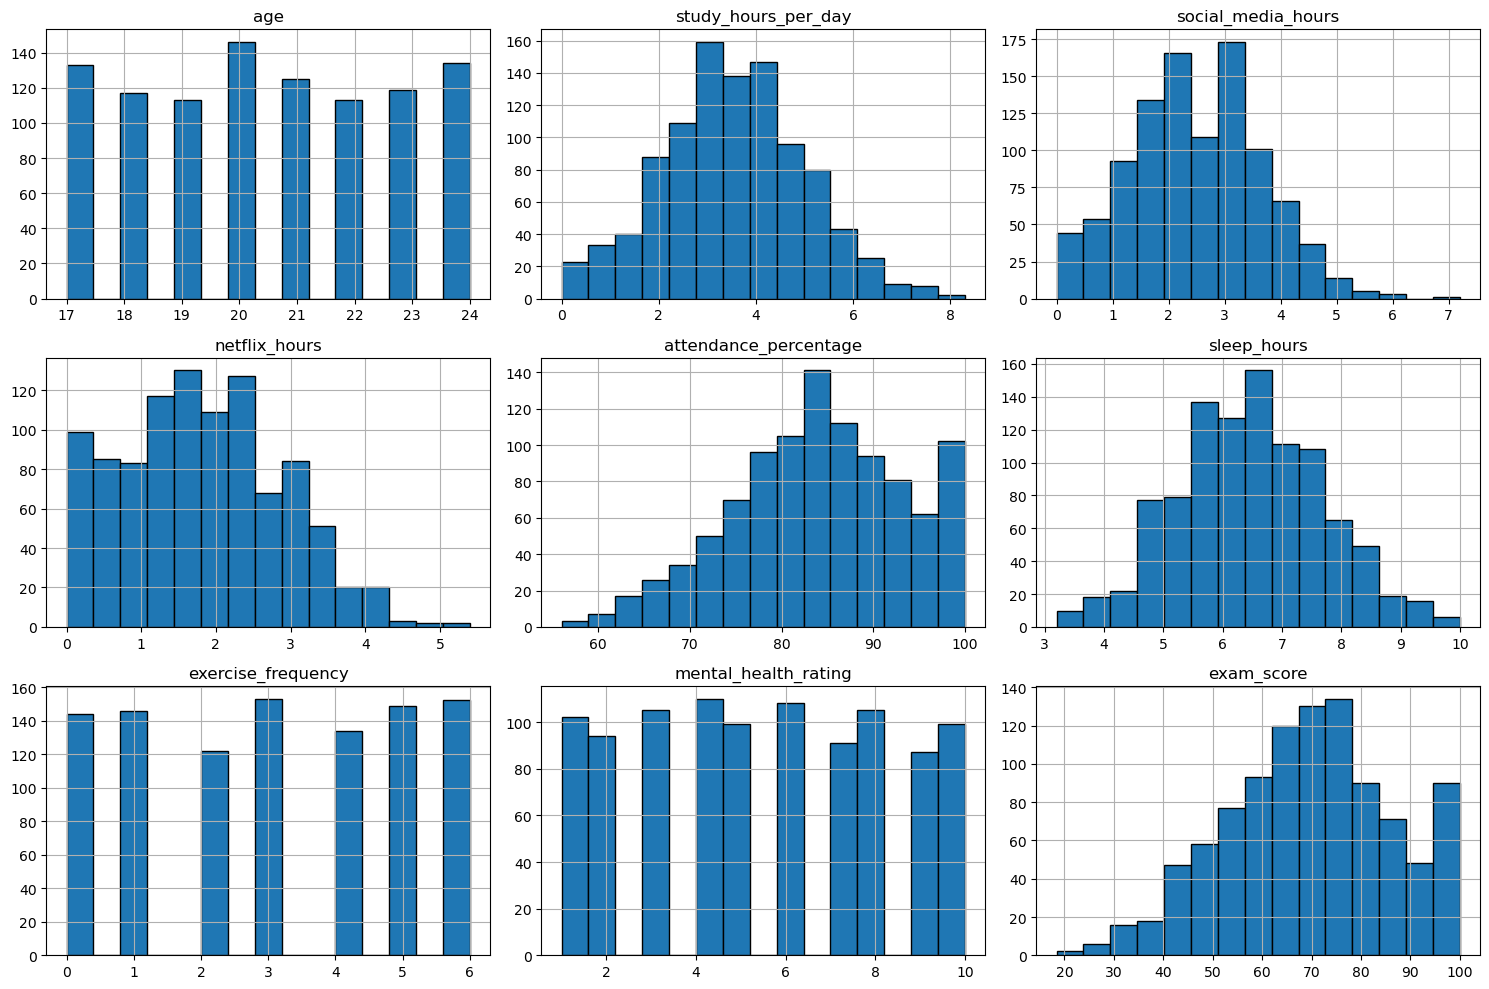

In [22]:
import matplotlib.pyplot as plt
df.hist(bins=15, figsize=(15, 10), edgecolor='black')
plt.tight_layout()
plt.show()

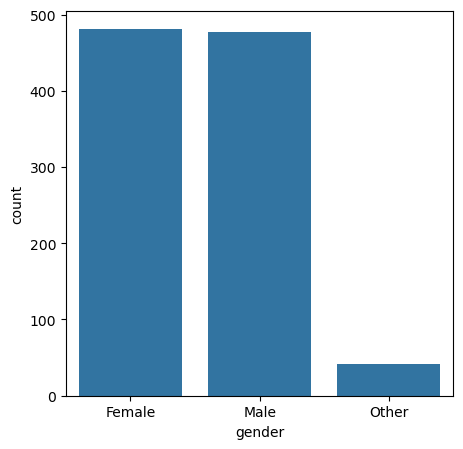

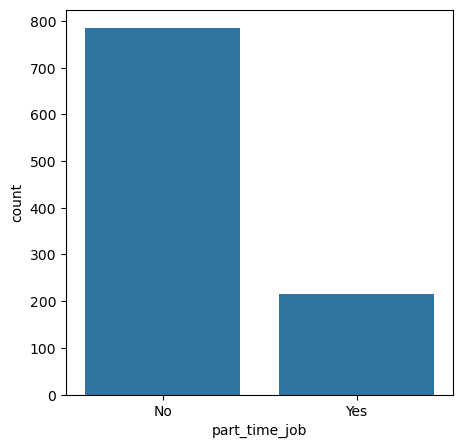

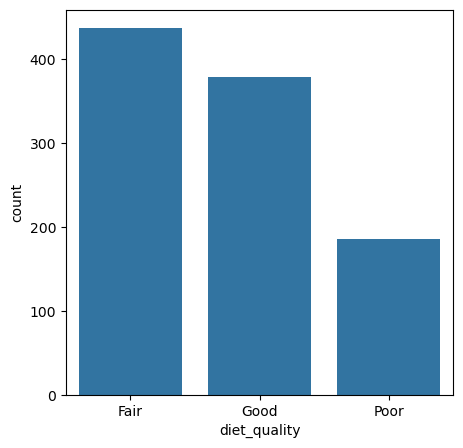

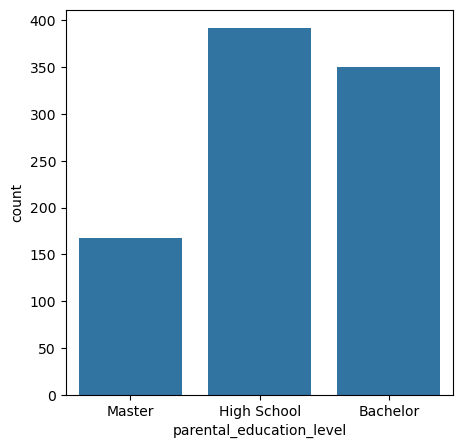

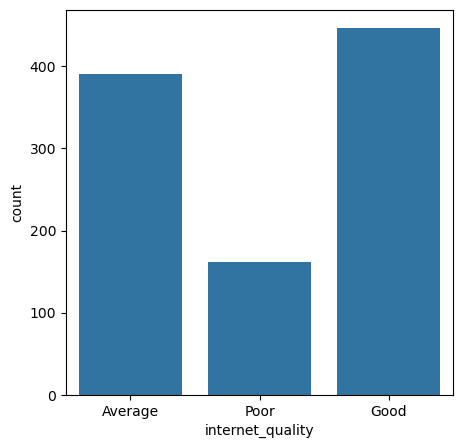

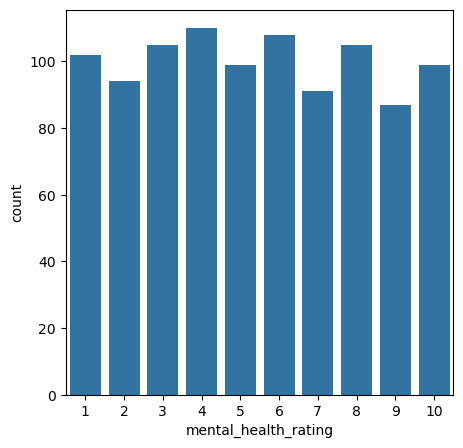

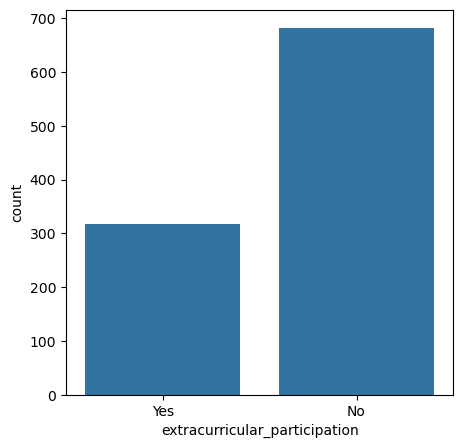

In [30]:
import seaborn as sns
for col in count_cols:
    plt.figure(figsize=(5, 5))
    sns.countplot(data = df, x= col)
    plt.show()

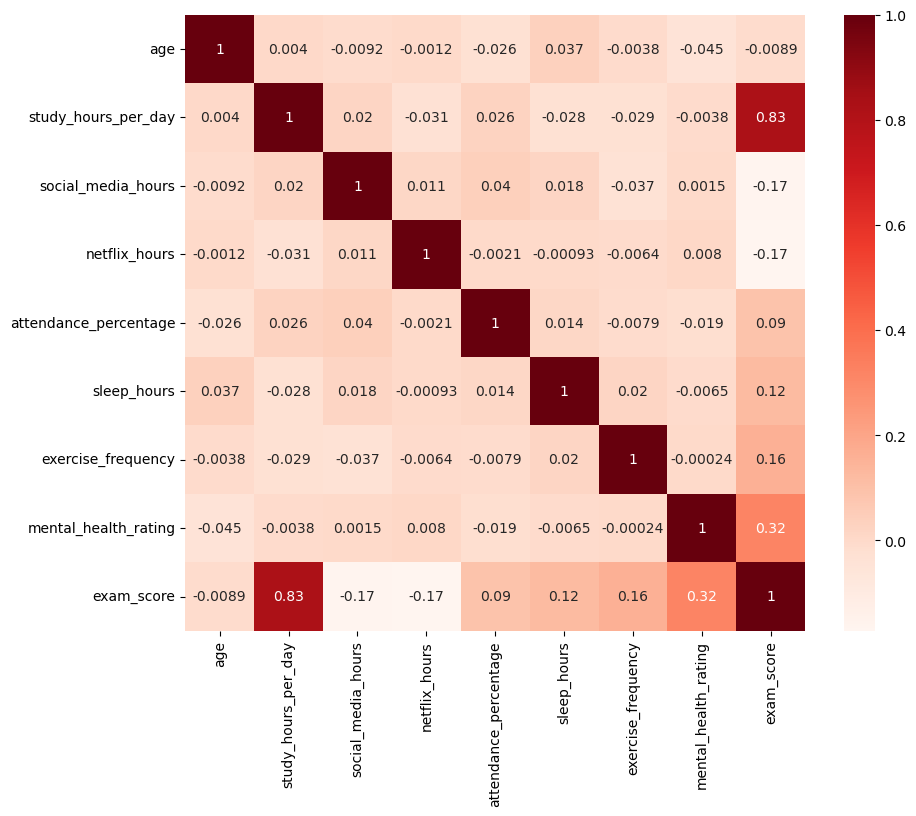

In [38]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only = True), annot =True, cmap = 'Reds')
plt.show()

In [39]:
df.columns

Index(['student_id', 'age', 'gender', 'study_hours_per_day',
       'social_media_hours', 'netflix_hours', 'part_time_job',
       'attendance_percentage', 'sleep_hours', 'diet_quality',
       'exercise_frequency', 'parental_education_level', 'internet_quality',
       'mental_health_rating', 'extracurricular_participation', 'exam_score'],
      dtype='object')

In [44]:
num_ft = ['study_hours_per_day','social_media_hours', 'netflix_hours', 'attendance_percentage', 'sleep_hours', 'exercise_frequency', 'exam_score' ]

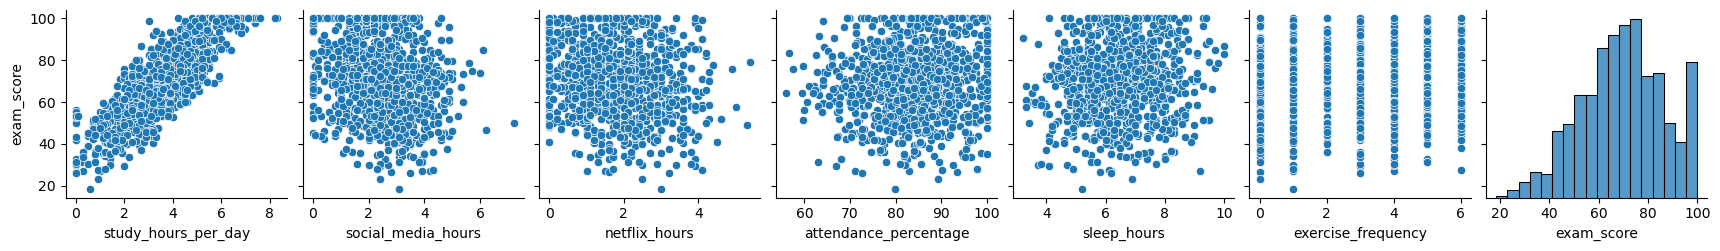

In [60]:
sns.pairplot(df, y_vars=['exam_score'], x_vars=num_ft)
plt.show()

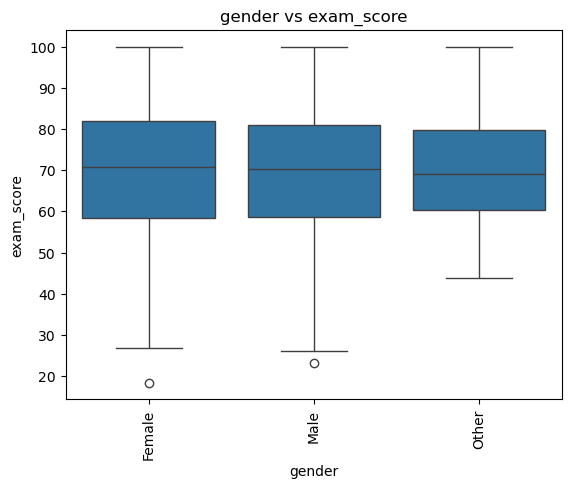

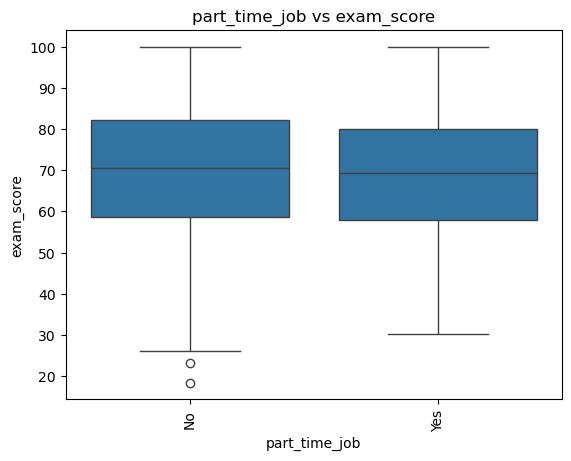

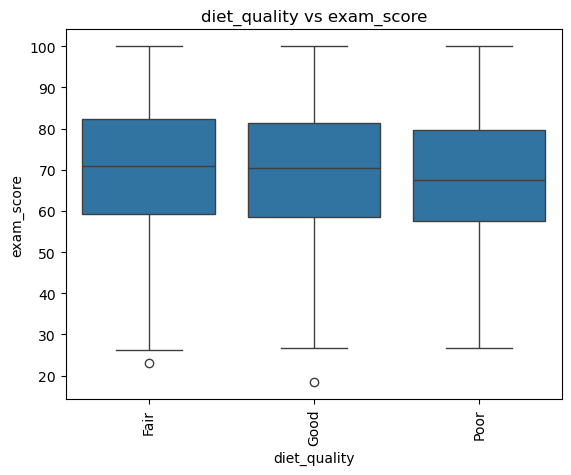

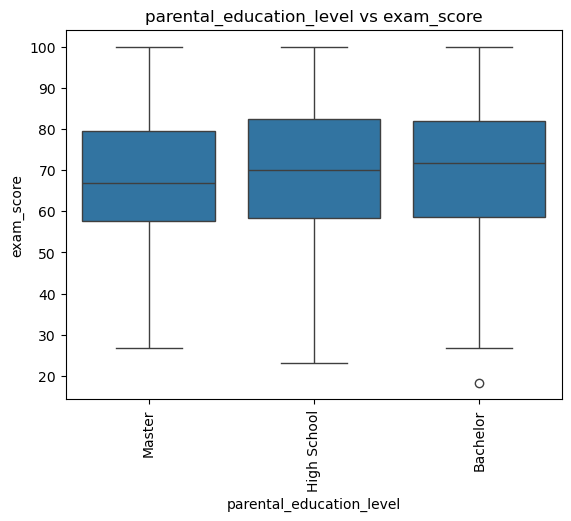

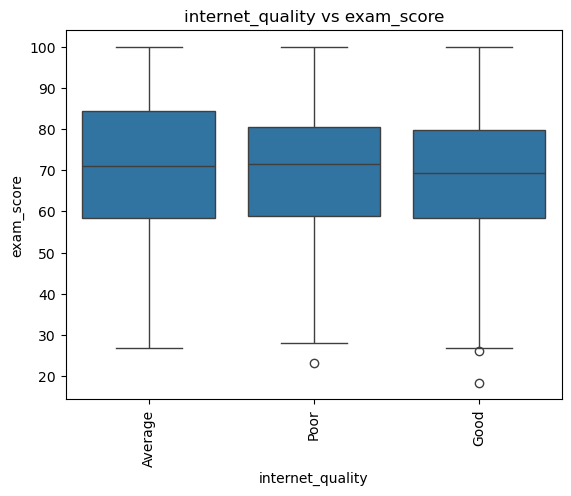

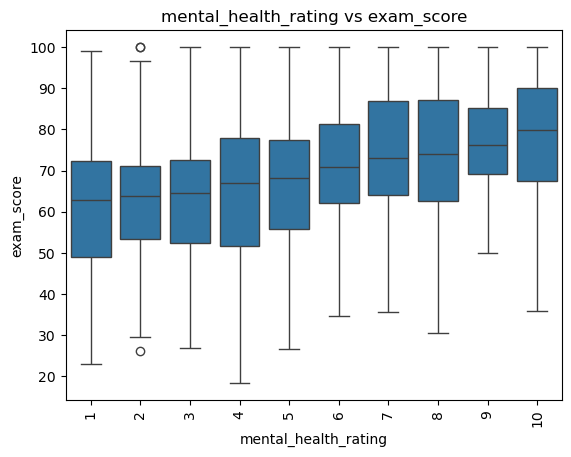

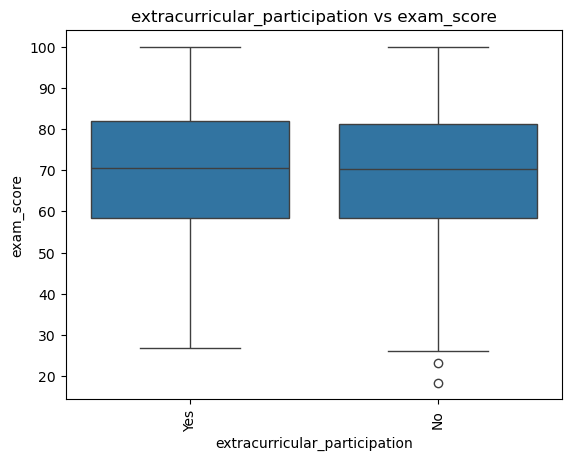

In [64]:
for col in count_cols:
    sns.boxplot(data=df, x=col, y='exam_score')
    plt.title(f"{col} vs exam_score")
    plt.xticks(rotation = 90)
    plt.show()

In [66]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor


In [67]:
df.columns

Index(['student_id', 'age', 'gender', 'study_hours_per_day',
       'social_media_hours', 'netflix_hours', 'part_time_job',
       'attendance_percentage', 'sleep_hours', 'diet_quality',
       'exercise_frequency', 'parental_education_level', 'internet_quality',
       'mental_health_rating', 'extracurricular_participation', 'exam_score'],
      dtype='object')

In [68]:
df_new = df

In [70]:
df_new['entertainment_hours'] = df_new['social_media_hours'] + df_new['netflix_hours']

In [73]:
df_new = df_new.drop(columns=['student_id', 'social_media_hours', 'netflix_hours'])

In [74]:
df_new

,age,gender,study_hours_per_day,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score,entertainment_hours
0,23,Female,0.0,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2,2.3
1,20,Female,6.9,No,97.3,4.6,Good,6,High School,Average,8,No,100.0,5.1
2,21,Male,1.4,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3,4.4
3,23,Female,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8,4.9
4,19,Female,5.0,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4,4.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,21,Female,2.6,No,77.0,7.5,Fair,2,High School,Good,6,Yes,76.1,2.1
996,17,Female,2.9,Yes,86.0,6.8,Poor,1,High School,Average,6,Yes,65.9,3.4
997,20,Male,3.0,No,61.9,6.5,Good,5,Bachelor,Good,9,Yes,64.4,3.9
998,24,Male,5.4,Yes,100.0,7.6,Fair,0,Bachelor,Average,1,No,69.7,5.2


In [78]:
num_ft2 = ['study_hours_per_day','entertainment_hours', 'attendance_percentage', 'sleep_hours', 'exercise_frequency', 'exam_score' ]

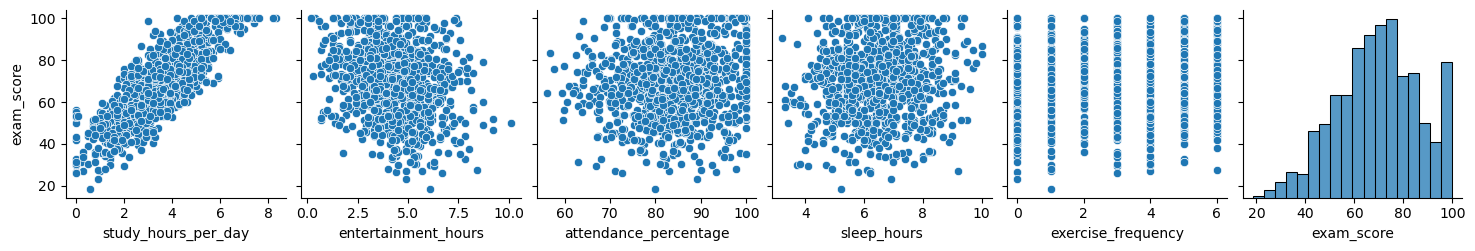

In [79]:
sns.pairplot(df_new, y_vars=['exam_score'], x_vars=num_ft2)
plt.show()

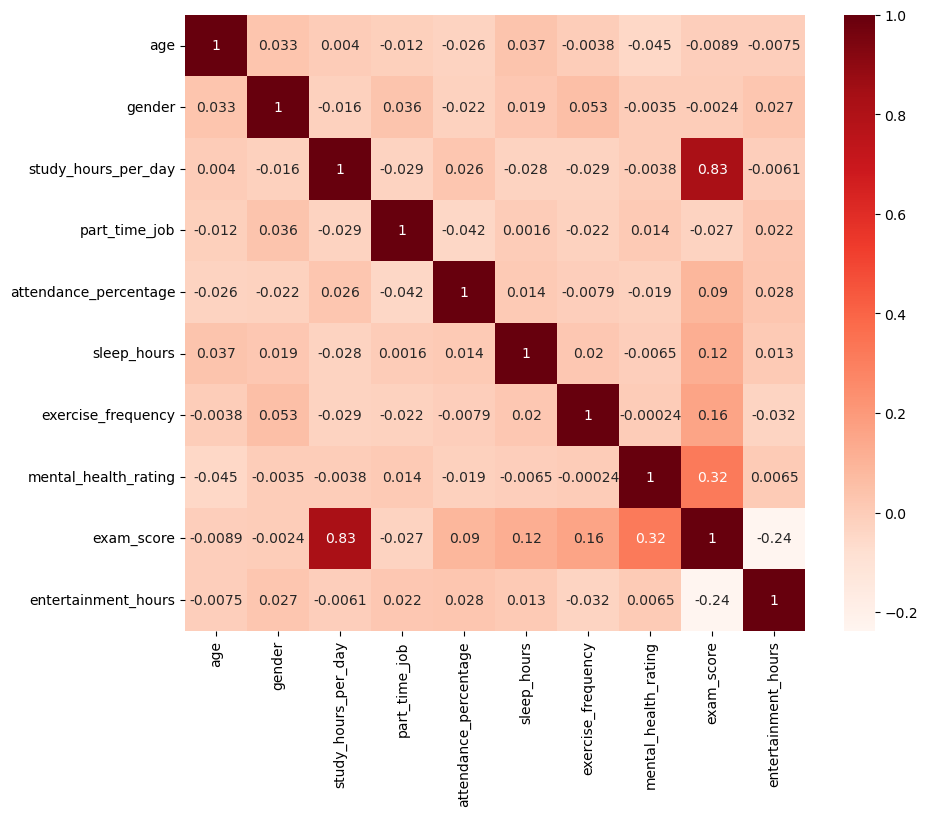

In [85]:
plt.figure(figsize=(10, 8))
sns.heatmap(df_new.corr(numeric_only = True), annot =True, cmap = 'Reds')
plt.show()

In [75]:
le = LabelEncoder()

In [ ]:
df_new['part_time_job'] = le.fit_transform(df_new['part_time_job'])

0---> No part time job

In [83]:
df_new['gender'] =le.fit_transform(df_new['gender'])

0--> female, 1---> male, 2----> others

In [84]:
df_new

,age,gender,study_hours_per_day,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score,entertainment_hours
0,23,0,0.0,0,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2,2.3
1,20,0,6.9,0,97.3,4.6,Good,6,High School,Average,8,No,100.0,5.1
2,21,1,1.4,0,94.8,8.0,Poor,1,High School,Poor,1,No,34.3,4.4
3,23,0,1.0,0,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8,4.9
4,19,0,5.0,0,90.9,4.9,Fair,3,Master,Good,1,No,66.4,4.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,21,0,2.6,0,77.0,7.5,Fair,2,High School,Good,6,Yes,76.1,2.1
996,17,0,2.9,1,86.0,6.8,Poor,1,High School,Average,6,Yes,65.9,3.4
997,20,1,3.0,0,61.9,6.5,Good,5,Bachelor,Good,9,Yes,64.4,3.9
998,24,1,5.4,1,100.0,7.6,Fair,0,Bachelor,Average,1,No,69.7,5.2


In [81]:
df_new.columns


Index(['age', 'gender', 'study_hours_per_day', 'part_time_job',
       'attendance_percentage', 'sleep_hours', 'diet_quality',
       'exercise_frequency', 'parental_education_level', 'internet_quality',
       'mental_health_rating', 'extracurricular_participation', 'exam_score',
       'entertainment_hours'],
      dtype='object')

In [86]:
ft1 = ['age', 'gender', 'study_hours_per_day', 'part_time_job',
       'attendance_percentage', 'sleep_hours', 'exercise_frequency', 'mental_health_rating', 'entertainment_hours']

In [87]:
target = ['exam_score']

In [89]:
df_new[ft1]

In [93]:
X = df_new[ft1]

In [94]:
y= df_new['exam_score']

In [95]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [119]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [123]:
from xgboost import XGBRegressor

In [124]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(max_depth=8, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
}

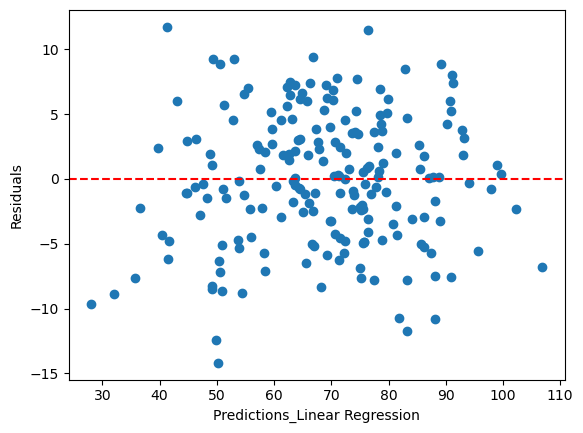

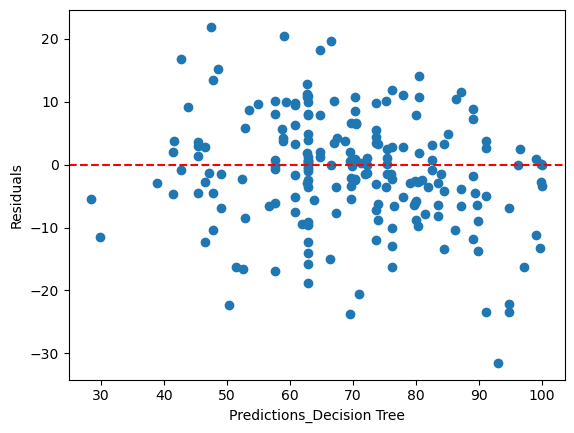

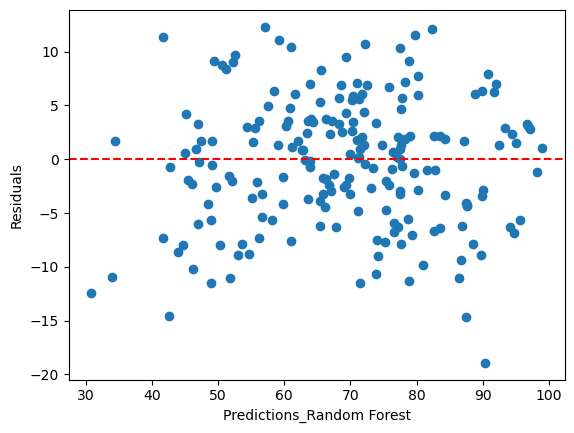

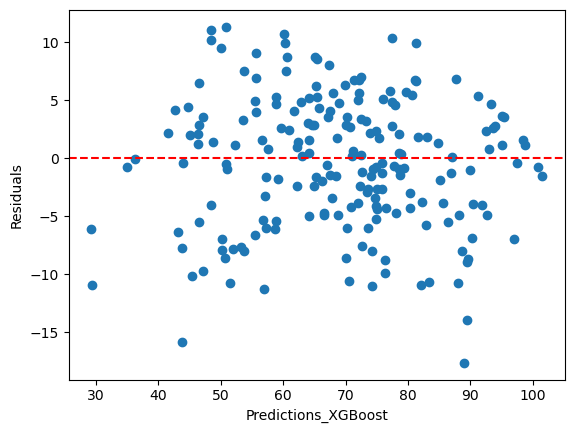

In [139]:
results1_data = []
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    predictions = model.predict(X_test_scaled)
    
    mse = mean_squared_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)
    
    results1_data.append({
        "Model": name,
        "MSE": mse,
        "R² Score": r2
    })
    
    residuals = y_test - predictions
    plt.scatter(predictions, residuals)
    plt.axhline(y=0, color='r', linestyle='--')
    plt.xlabel(f"Predictions_{name}")
    plt.ylabel("Residuals")
    plt.show()

In [140]:
results1_data

[{'Model': 'Linear Regression',
  'MSE': 25.938966132913254,
  'R² Score': 0.8988454643504524},
 {'Model': 'Decision Tree',
  'MSE': 80.87606546271294,
  'R² Score': 0.6846065180422702},
 {'Model': 'Random Forest',
  'MSE': 35.652541433023295,
  'R² Score': 0.8609653039020841},
 {'Model': 'XGBoost',
  'MSE': 32.895112503537256,
  'R² Score': 0.8717184866434297}]

In [142]:
param_grid_lr = {'alpha': [0.1, 1.0, 5.0, 10.0, 100.0]}

grid_lr = GridSearchCV(Ridge(), param_grid_lr, cv=5, scoring='r2')
grid_lr.fit(X_train_scaled, y_train)

print(f"Best Ridge Alpha: {grid_lr.best_params_}")
print(f"Best R²: {grid_lr.best_score_:.2f}")

Best Ridge Alpha: {'alpha': 1.0}
Best R²: 0.90


Best Ridge Alpha: {'alpha': 1.0}
Best R²: 0.90
(with ft1)

In [144]:
tuned_models = {
    "Random Forest": {
        "model": RandomForestRegressor(random_state=42),
        "params": {
            'n_estimators': [100, 150, 200],
            'max_depth': [5, 10, 15, 20],
            'min_samples_split': [2, 5]
        }
    },
    "XGBoost": {
        "model": XGBRegressor(random_state=42),
        "params": {
            'n_estimators': [100, 150, 200],
            'learning_rate': [0.01, 0.1, 0.9],
            'max_depth': [3, 5, 7]
        }
    }
}

for name, config in tuned_models.items():
    grid = GridSearchCV(config["model"], config["params"], cv=5, scoring='r2', n_jobs=-1)
    grid.fit(X_train_scaled, y_train)
    print(f"--- {name} Optimized ---")
    print(f"Best Params: {grid.best_params_}")
    print(f"Best Score: {grid.best_score_:.2f}\n")

--- Random Forest Optimized ---
Best Params: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}
Best Score: 0.86

--- XGBoost Optimized ---
Best Params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
Best Score: 0.88



--- Random Forest Optimized --- with ft1
Best Params: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}
Best Score: 0.86

--- XGBoost Optimized --- with ft1
Best Params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
Best Score: 0.88

In [145]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression

selector = RFE(estimator=LinearRegression(), n_features_to_select=5, step=1)
selector = selector.fit(X_train_scaled, y_train)

print("Selected Features:", X.columns[selector.support_])

Selected Features: Index(['study_hours_per_day', 'sleep_hours', 'exercise_frequency',
       'mental_health_rating', 'entertainment_hours'],
      dtype='object')


In [151]:
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rfe_rf = RFE(estimator=rf, n_features_to_select=5, step=1)
rfe_rf.fit(X_train_scaled, y_train)

print("Best Features (via RF):", X.columns[rfe_rf.support_])

Best Features (via RF): Index(['study_hours_per_day', 'sleep_hours', 'exercise_frequency',
       'mental_health_rating', 'entertainment_hours'],
      dtype='object')


In [148]:
xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
rfe_xgb = RFE(estimator=xgb, n_features_to_select=5, step=1)
rfe_xgb.fit(X_train_scaled, y_train)

print("Best Features (via XGBoost):", X.columns[rfe_xgb.support_])

Best Features (via XGBoost): Index(['study_hours_per_day', 'sleep_hours', 'exercise_frequency',
       'mental_health_rating', 'entertainment_hours'],
      dtype='object')


In [147]:
print(ft1)

['age', 'gender', 'study_hours_per_day', 'part_time_job', 'attendance_percentage', 'sleep_hours', 'exercise_frequency', 'mental_health_rating', 'entertainment_hours']


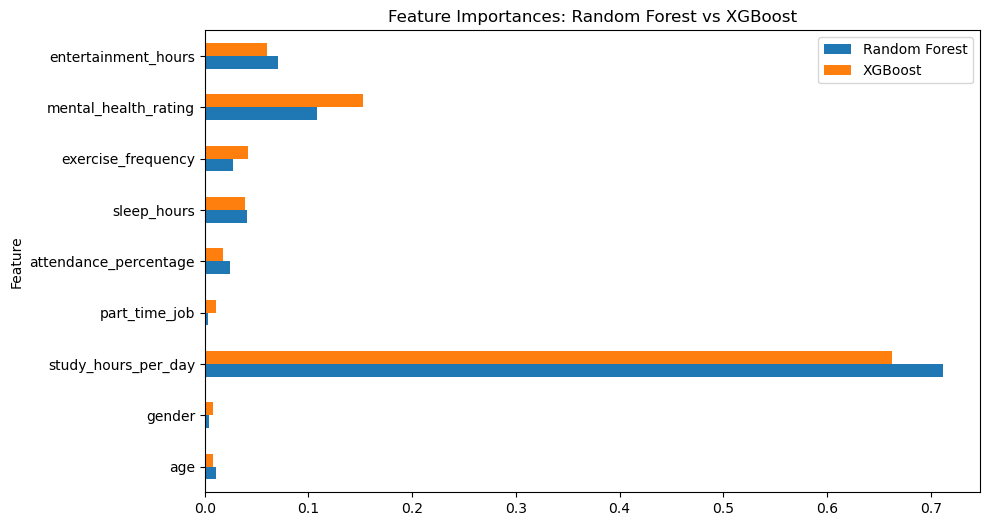

In [154]:
rf.fit(X_train_scaled, y_train)
xgb.fit(X_train_scaled, y_train)

feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Random Forest': rf.feature_importances_,
    'XGBoost': xgb.feature_importances_
})

feature_importances.set_index('Feature', inplace=True)
feature_importances.plot(kind='barh', figsize=(10, 6))
plt.title('Feature Importances: Random Forest vs XGBoost')
plt.show()

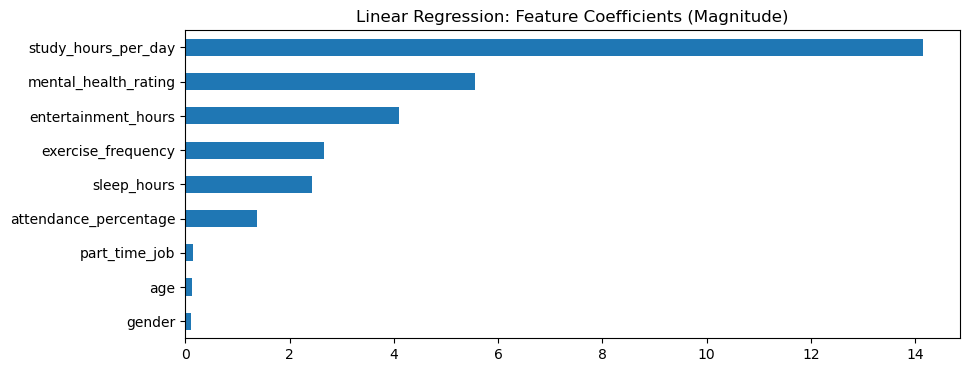

In [156]:
lr_importances = pd.Series(lr.coef_, index=X.columns)
lr_importances.abs().sort_values().plot(kind='barh', figsize=(10, 4))
plt.title('Linear Regression: Feature Coefficients (Magnitude)')
plt.show()

In [158]:
import joblib 
final_model = grid_lr.best_estimator_

joblib.dump(final_model, 'student_perf_model.pkl')

['student_perf_model.pkl']